# 08_residual_diagnostics_and_operating_regimes.ipynb

## Σκοπός του notebook

Το παρόν notebook αποτελεί το **strict downstream diagnostics stage** του current forecasting-first pipeline.

Ο ρόλος του είναι αυστηρά **downstream**:

- δεν εκπαιδεύει νέα μοντέλα,
- δεν αλλάζει το upstream feature space,
- δεν επηρεάζει το canonical benchmark artifact,
- και δεν μετακινεί το repository σε νέο modeling stage.

Στόχος είναι να εξεταστεί αν τα residuals των ήδη υλοποιημένων baselines εμφανίζουν:

- μη ομοιογενή κατανομή,
- systematic bias direction,
- διαφοροποίηση ανά operating regime,
- και κοινές ή αποκλίνουσες περιοχές δυσκολίας στο κοινό test-only evaluation space.

## Thesis-ready framing

Η σωστή θέση του `NB08` είναι η εξής:

**benchmarked forecasting -> downstream residual diagnostics -> cautious condition-awareness-oriented interpretation**

Άρα το notebook λειτουργεί ως **ερμηνευτική επέκταση** του benchmark stack και όχι ως νέο predictive stage.

## Τι δεν κάνει αυτό το notebook

Το notebook αυτό δεν:

- εισάγει νέο training,
- δεν κάνει νέο modeling stage,
- δεν κάνει graph training,
- δεν εισάγει GNN benchmark,
- δεν ανοίγει sequence modeling,
- δεν κάνει anomaly detection claims,
- δεν κάνει fault diagnosis claims,
- δεν κάνει PHM claims,
- και δεν αλλάζει benchmark artifacts upstream.

## Canonical downstream contract

Το `NB08` καταναλώνει μόνο canonical exported artifacts από τα upstream notebooks:

- `test_final.csv`
- `baseline_metrics.csv`
- `nb06_test_predictions.csv`
- `nb07_all_test_predictions_long.csv` ή deterministic fallback στα επιμέρους NB07 exports

Άρα το notebook παραμένει:

- **test-only diagnostics notebook**,
- **benchmark-safe downstream stage**,
- **canonical-artifact consumer**,
- και **strict residual-analysis notebook**, όχι νέο forecasting notebook.

In [1]:
# ============================================================
# NB08 | Imports και display setup
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Κρατάμε το output καθαρό και σταθερό για thesis-ready reruns.
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.6f}".format)

print("NB08 environment initialized successfully.")

NB08 environment initialized successfully.


In [2]:
# ============================================================
# NB08 | Path helpers
# ============================================================

def find_project_root(start_path: Path) -> Path:
    """
    Εντοπίζει το project root ανεβαίνοντας από το current working directory.

    Απαιτούμε να υπάρχουν τουλάχιστον:
    - data/
    - notebooks/
    """
    current = start_path.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Δεν βρέθηκε project root με φακέλους 'data/' και 'notebooks/'."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
PREDICTIONS_DIR = DATA_PROCESSED / "predictions"
DIAGNOSTICS_DIR = DATA_PROCESSED / "diagnostics"

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"DATA_PROCESSED = {DATA_PROCESSED}")

PROJECT_ROOT = C:\Users\diony\Desktop\WindPower_DigitalTwin
DATA_PROCESSED = C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed


In [3]:
# ============================================================
# NB08 | Constants και canonical paths
# ============================================================

TEST_PATH = DATA_PROCESSED / "test_final.csv"
BENCHMARK_PATH = DATA_PROCESSED / "baseline_metrics.csv"
NB06_PRED_PATH = DATA_PROCESSED / "nb06_test_predictions.csv"

# NB07 canonical long export
NB07_ALL_PRED_PATH = PREDICTIONS_DIR / "nb07_all_test_predictions_long.csv"

# NB07 fallback individual exports
NB07_RF_PRED_PATH = PREDICTIONS_DIR / "nb07_random_forest_test_predictions.csv"
NB07_XGB_PRED_PATH = PREDICTIONS_DIR / "nb07_xgboost_test_predictions.csv"
NB07_MLP_PRED_PATH = PREDICTIONS_DIR / "nb07_mlp_test_predictions.csv"

PARK_ID_COLUMN = "park_id"
TIMESTAMP_COLUMN = "timestamp"
FLAG_COLUMN = "test_flag"
TARGET_COLUMN = "Power_Output_Normalized"
BASELINE_COLUMN = "Baseline_Prediction"

CANONICAL_BENCHMARK_COLUMNS = ["Model", "MAE", "RMSE", "R2"]
EXPECTED_MODELS = [
    "Persistence",
    "Linear Regression",
    "Random Forest",
    "XGBoost",
    "MLP",
]

REQUIRED_TEST_COLUMNS = {
    PARK_ID_COLUMN,
    TIMESTAMP_COLUMN,
    FLAG_COLUMN,
    TARGET_COLUMN,
    "Wind_Speed_100m_ms",
    "ws_ref",
    "hour",
    "month",
    "hub_height_m",
    "nominal_power_kW",
    "turbine",
}

REQUIRED_PRED_COLUMNS = {
    PARK_ID_COLUMN,
    TIMESTAMP_COLUMN,
    "model",
    "y_true",
    "y_pred",
}

print("Canonical constants defined.")

Canonical constants defined.


In [4]:
# ============================================================
# NB08 | Core loading / validation utilities
# ============================================================

def standardize_park_id(series: pd.Series) -> pd.Series:
    """
    Μετατρέπει park_id σε zero-padded string για deterministic joins.
    """
    return (
        series.astype("string")
        .str.strip()
        .str.replace(".0", "", regex=False)
        .str.zfill(5)
    )


def parse_timestamp_strict(series: pd.Series, column_name: str) -> pd.Series:
    """
    Strict datetime parsing για downstream notebooks.
    """
    parsed = pd.to_datetime(series, errors="coerce", format="%Y-%m-%d %H:%M:%S")

    if parsed.isna().any():
        bad_count = int(parsed.isna().sum())
        raise ValueError(
            f"Αποτυχία strict datetime parsing στη στήλη '{column_name}'. "
            f"NaT count = {bad_count}"
        )

    return parsed


def assert_required_columns(df: pd.DataFrame, required_columns, df_name: str) -> None:
    """
    Fail-fast έλεγχος required columns.
    """
    missing = sorted(set(required_columns) - set(df.columns))
    if missing:
        raise KeyError(
            f"Το dataframe '{df_name}' λείπουν required columns: {missing}"
        )


def assert_unique_keys(
    df: pd.DataFrame,
    key_cols,
    df_name: str,
) -> None:
    """
    Ελέγχει ότι τα key columns είναι unique.
    """
    dup_count = int(df.duplicated(key_cols).sum())
    if dup_count > 0:
        raise ValueError(
            f"Βρέθηκαν {dup_count} duplicate rows στο '{df_name}' "
            f"πάνω στα keys {key_cols}."
        )


def load_test_artifact(csv_path: Path) -> pd.DataFrame:
    """
    Φορτώνει το canonical test split με strict downstream contract.
    """
    if not csv_path.exists():
        raise FileNotFoundError(f"Λείπει το required file: {csv_path}")

    df = pd.read_csv(csv_path)
    assert_required_columns(df, REQUIRED_TEST_COLUMNS, "test_final")

    df[PARK_ID_COLUMN] = standardize_park_id(df[PARK_ID_COLUMN])
    df[TIMESTAMP_COLUMN] = parse_timestamp_strict(df[TIMESTAMP_COLUMN], TIMESTAMP_COLUMN)

    assert_unique_keys(df, [PARK_ID_COLUMN, TIMESTAMP_COLUMN], "test_final")

    # Deterministic ordering
    df = df.sort_values([PARK_ID_COLUMN, TIMESTAMP_COLUMN], kind="mergesort").reset_index(drop=True)

    return df


def load_prediction_export(csv_path: Path, export_name: str) -> pd.DataFrame:
    """
    Φορτώνει prediction export με canonical schema.
    """
    if not csv_path.exists():
        raise FileNotFoundError(f"Λείπει το required prediction export: {csv_path}")

    df = pd.read_csv(csv_path)
    assert_required_columns(df, REQUIRED_PRED_COLUMNS, export_name)

    df[PARK_ID_COLUMN] = standardize_park_id(df[PARK_ID_COLUMN])
    df[TIMESTAMP_COLUMN] = parse_timestamp_strict(df[TIMESTAMP_COLUMN], TIMESTAMP_COLUMN)

    # Null checks
    null_total = int(df[list(REQUIRED_PRED_COLUMNS)].isna().sum().sum())
    if null_total > 0:
        raise ValueError(
            f"Βρέθηκαν null values στο prediction export '{export_name}'. "
            f"Null total = {null_total}"
        )

    assert_unique_keys(
        df,
        [PARK_ID_COLUMN, TIMESTAMP_COLUMN, "model"],
        export_name,
    )

    df = df.sort_values(
        [PARK_ID_COLUMN, TIMESTAMP_COLUMN, "model"],
        kind="mergesort"
    ).reset_index(drop=True)

    return df


def load_benchmark_artifact(csv_path: Path) -> pd.DataFrame:
    """
    Φορτώνει το canonical benchmark artifact.
    """
    if not csv_path.exists():
        raise FileNotFoundError(f"Λείπει το benchmark artifact: {csv_path}")

    df = pd.read_csv(csv_path)

    if list(df.columns) != CANONICAL_BENCHMARK_COLUMNS:
        raise ValueError(
            "Το baseline_metrics.csv δεν έχει canonical schema. "
            f"Expected={CANONICAL_BENCHMARK_COLUMNS}, found={list(df.columns)}"
        )

    if df["Model"].duplicated().any():
        dup_models = df.loc[df["Model"].duplicated(), "Model"].tolist()
        raise ValueError(f"Duplicate model rows στο benchmark artifact: {dup_models}")

    return df.copy()

In [5]:
# ============================================================
# NB08 | NB07 prediction loading with fallback logic
# ============================================================

def load_nb07_predictions() -> pd.DataFrame:
    """
    Προτιμά το canonical NB07 long export.
    Αν λείπει, δοκιμάζει fallback στα individual exports.
    """
    if NB07_ALL_PRED_PATH.exists():
        nb07_df = load_prediction_export(NB07_ALL_PRED_PATH, "nb07_all_test_predictions_long")

        expected_nb07_models = {"Random Forest", "XGBoost", "MLP"}
        found_nb07_models = set(nb07_df["model"].astype(str).unique())

        if found_nb07_models != expected_nb07_models:
            raise ValueError(
                "Το NB07 long export δεν έχει τα αναμενόμενα model names. "
                f"Expected={sorted(expected_nb07_models)}, found={sorted(found_nb07_models)}"
            )

        return nb07_df

    # Fallback στα individual exports
    fallback_paths = {
        "Random Forest": NB07_RF_PRED_PATH,
        "XGBoost": NB07_XGB_PRED_PATH,
        "MLP": NB07_MLP_PRED_PATH,
    }

    missing_exports = [
        f"{model}: {path}" for model, path in fallback_paths.items() if not path.exists()
    ]
    if missing_exports:
        raise FileNotFoundError(
            "Δεν βρέθηκε ούτε το canonical NB07 long export ούτε όλα τα fallback individual exports.\n"
            + "\n".join(missing_exports)
        )

    dfs = []
    for model_name, export_path in fallback_paths.items():
        pred_df = load_prediction_export(export_path, f"NB07 {model_name}")
        found_models = set(pred_df["model"].astype(str).unique())

        if found_models != {model_name}:
            raise ValueError(
                f"Το export '{export_path.name}' δεν περιέχει μόνο το model '{model_name}'. "
                f"Found={sorted(found_models)}"
            )

        dfs.append(pred_df)

    nb07_df = pd.concat(dfs, axis=0, ignore_index=True)
    nb07_df = nb07_df.sort_values(
        [PARK_ID_COLUMN, TIMESTAMP_COLUMN, "model"],
        kind="mergesort"
    ).reset_index(drop=True)

    return nb07_df

## Γιατί προηγείται provenance / integrity audit

Πριν αναλυθούν residuals και operating regimes, πρέπει να επιβεβαιωθεί ότι:

- όλα τα prediction exports αναφέρονται στο ίδιο canonical test backbone,
- δεν λείπουν observations,
- δεν υπάρχουν duplicate keys,
- τα `y_true` των exports συμφωνούν με το canonical target του `test_final.csv`,
- και δεν υπάρχει benchmark contamination ή mismatch ανά model.

Το `NB08` πρέπει να αποτυγχάνει νωρίς αν ο downstream handoff από τα `NB05`, `NB06`, `NB07` δεν είναι πλήρως συνεπής.

In [6]:
# ============================================================
# NB08 | Load canonical artifacts
# ============================================================

test_df = load_test_artifact(TEST_PATH)
benchmark_df = load_benchmark_artifact(BENCHMARK_PATH)
nb06_pred_df = load_prediction_export(NB06_PRED_PATH, "nb06_test_predictions")
nb07_pred_df = load_nb07_predictions()

print("Loaded artifacts successfully.")
print(f"test_final shape              : {test_df.shape}")
print(f"baseline_metrics shape        : {benchmark_df.shape}")
print(f"nb06_test_predictions shape   : {nb06_pred_df.shape}")
print(f"nb07_predictions shape        : {nb07_pred_df.shape}")

Loaded artifacts successfully.
test_final shape              : (1086336, 47)
baseline_metrics shape        : (5, 4)
nb06_test_predictions shape   : (2172672, 5)
nb07_predictions shape        : (3259008, 5)


In [7]:
# ============================================================
# NB08 | Quick artifact audit
# ============================================================

artifact_audit = pd.DataFrame(
    [
        {
            "artifact": "test_final.csv",
            "rows": len(test_df),
            "cols": test_df.shape[1],
            "unique_parks": test_df[PARK_ID_COLUMN].nunique(),
            "timestamp_min": test_df[TIMESTAMP_COLUMN].min(),
            "timestamp_max": test_df[TIMESTAMP_COLUMN].max(),
        },
        {
            "artifact": "nb06_test_predictions.csv",
            "rows": len(nb06_pred_df),
            "cols": nb06_pred_df.shape[1],
            "unique_models": nb06_pred_df["model"].nunique(),
            "timestamp_min": nb06_pred_df[TIMESTAMP_COLUMN].min(),
            "timestamp_max": nb06_pred_df[TIMESTAMP_COLUMN].max(),
        },
        {
            "artifact": "nb07_predictions",
            "rows": len(nb07_pred_df),
            "cols": nb07_pred_df.shape[1],
            "unique_models": nb07_pred_df["model"].nunique(),
            "timestamp_min": nb07_pred_df[TIMESTAMP_COLUMN].min(),
            "timestamp_max": nb07_pred_df[TIMESTAMP_COLUMN].max(),
        },
    ]
)

artifact_audit

,artifact,rows,cols,unique_parks,timestamp_min,timestamp_max,unique_models
0,test_final.csv,1086336,47,256.000000,2019-12-01 01:00:00,2020-06-01 23:00:00,NaN
1,nb06_test_predictions.csv,2172672,5,NaN,2019-12-01 01:00:00,2020-06-01 23:00:00,2.000000
2,nb07_predictions,3259008,5,NaN,2019-12-01 01:00:00,2020-06-01 23:00:00,3.000000


In [8]:
# ============================================================
# NB08 | Build canonical evaluation space
# ============================================================

# Συνένωση NB06 + NB07 prediction exports
all_pred_df = pd.concat([nb06_pred_df, nb07_pred_df], axis=0, ignore_index=True)

# Deterministic sort
all_pred_df = all_pred_df.sort_values(
    [PARK_ID_COLUMN, TIMESTAMP_COLUMN, "model"],
    kind="mergesort"
).reset_index(drop=True)

# Strict model set check
found_models = list(pd.unique(all_pred_df["model"]))
missing_models = sorted(set(EXPECTED_MODELS) - set(found_models))
unknown_models = sorted(set(found_models) - set(EXPECTED_MODELS))

if missing_models:
    raise ValueError(f"Λείπουν models από το combined prediction space: {missing_models}")
if unknown_models:
    raise ValueError(f"Βρέθηκαν unknown models στο combined prediction space: {unknown_models}")

print("Combined prediction space constructed successfully.")
print(f"Combined rows = {len(all_pred_df):,}")
print(f"Models        = {sorted(found_models)}")

Combined prediction space constructed successfully.
Combined rows = 5,431,680
Models        = ['Linear Regression', 'MLP', 'Persistence', 'Random Forest', 'XGBoost']


In [9]:
# ============================================================
# NB08 | Exact key-space integrity checks
# ============================================================

test_key_df = test_df[[PARK_ID_COLUMN, TIMESTAMP_COLUMN]].copy()
test_key_df["__key__"] = (
    test_key_df[PARK_ID_COLUMN].astype(str) + "||" +
    test_key_df[TIMESTAMP_COLUMN].dt.strftime("%Y-%m-%d %H:%M:%S")
)

test_keys = set(test_key_df["__key__"])
expected_rows_per_model = len(test_df)

coverage_rows = []
for model_name, model_df in all_pred_df.groupby("model", observed=True):
    model_key = (
        model_df[PARK_ID_COLUMN].astype(str) + "||" +
        model_df[TIMESTAMP_COLUMN].dt.strftime("%Y-%m-%d %H:%M:%S")
    )
    model_keys = set(model_key)

    missing_key_count = len(test_keys - model_keys)
    extra_key_count = len(model_keys - test_keys)

    if len(model_df) != expected_rows_per_model:
        raise ValueError(
            f"Το model '{model_name}' δεν έχει ακριβώς {expected_rows_per_model:,} rows. "
            f"Found={len(model_df):,}"
        )

    if missing_key_count > 0:
        raise ValueError(
            f"Το model '{model_name}' λείπουν {missing_key_count} test keys."
        )

    if extra_key_count > 0:
        raise ValueError(
            f"Το model '{model_name}' έχει {extra_key_count} extra keys εκτός canonical test space."
        )

    coverage_rows.append(
        {
            "model": model_name,
            "rows": len(model_df),
            "missing_keys": missing_key_count,
            "extra_keys": extra_key_count,
        }
    )

coverage_audit_df = pd.DataFrame(coverage_rows).sort_values("model").reset_index(drop=True)
coverage_audit_df

,model,rows,missing_keys,extra_keys
0,Linear Regression,1086336,0,0
1,MLP,1086336,0,0
2,Persistence,1086336,0,0
3,Random Forest,1086336,0,0
4,XGBoost,1086336,0,0


In [10]:
# ============================================================
# NB08 | y_true consistency check against canonical target
# ============================================================

canonical_target_df = test_df[[PARK_ID_COLUMN, TIMESTAMP_COLUMN, TARGET_COLUMN]].copy()

merged_truth_check = all_pred_df.merge(
    canonical_target_df,
    on=[PARK_ID_COLUMN, TIMESTAMP_COLUMN],
    how="left",
    validate="many_to_one",
)

if merged_truth_check[TARGET_COLUMN].isna().any():
    raise ValueError("Βρέθηκαν prediction rows που δεν ταιριάζουν με canonical test target rows.")

truth_diff = np.abs(
    merged_truth_check["y_true"].to_numpy() -
    merged_truth_check[TARGET_COLUMN].to_numpy()
)

max_truth_diff = float(np.max(truth_diff))
if max_truth_diff > 1e-12:
    raise ValueError(
        "Τα prediction exports δεν συμφωνούν με το canonical target του test split. "
        f"Max abs diff = {max_truth_diff}"
    )

print("Prediction y_true values are fully consistent with test_final target values.")
print(f"Max absolute difference = {max_truth_diff:.12f}")

Prediction y_true values are fully consistent with test_final target values.
Max absolute difference = 0.000000000000


## Benchmark context

Το `baseline_metrics.csv` αντιμετωπίζεται εδώ ως **read-only benchmark context**.

Το `NB08`:

- δεν τροποποιεί benchmark rows,
- δεν ξαναϋπολογίζει final ranking για thesis reporting,
- δεν χρησιμοποιεί validation metrics για νέα επιλογή μοντέλου,
- και δεν μετακινεί το benchmark backbone σε άλλη evaluation logic.

Η συμβολή του notebook είναι συμπληρωματική:

από το ερώτημα  
**«ποιο μοντέλο είναι συνολικά καλύτερο;»**

στο ερώτημα  
**«πώς κατανέμεται το forecasting error, πού συγκεντρώνεται, και σε ποια operating conditions αλλάζει ο χαρακτήρας του;»**

In [11]:
# ============================================================
# NB08 | Canonical benchmark context
# ============================================================

benchmark_ranked = benchmark_df.sort_values("MAE", kind="mergesort").reset_index(drop=True)
benchmark_ranked["rank_by_mae"] = np.arange(1, len(benchmark_ranked) + 1)

# Χρήσιμο model order για plots
model_order = benchmark_ranked["Model"].tolist()

best_overall_model = benchmark_ranked.loc[0, "Model"]
linear_reference_model = "Linear Regression"

print(f"Best overall model according to current benchmark artifact: {best_overall_model}")
benchmark_ranked

Best overall model according to current benchmark artifact: XGBoost


,Model,MAE,RMSE,R2,rank_by_mae
0,XGBoost,0.065750,0.113494,0.860348,1
1,MLP,0.068008,0.115343,0.855760,2
2,Persistence,0.069832,0.130409,0.815620,3
3,Random Forest,0.070963,0.118826,0.846918,4
4,Linear Regression,0.072721,0.120307,0.843077,5


In [12]:
# ============================================================
# NB08 | Join predictions with canonical test backbone
# ============================================================

diagnostic_columns = [
    PARK_ID_COLUMN,
    TIMESTAMP_COLUMN,
    TARGET_COLUMN,
    FLAG_COLUMN,
    BASELINE_COLUMN,
    "Wind_Speed_100m_ms",
    "ws_ref",
    "hour",
    "month",
    "hub_height_m",
    "nominal_power_kW",
    "turbine",
]

analysis_df = all_pred_df.merge(
    test_df[diagnostic_columns],
    on=[PARK_ID_COLUMN, TIMESTAMP_COLUMN],
    how="left",
    validate="many_to_one",
)

# Fail-fast null check μετά το join με το canonical backbone.
joined_null_total = int(analysis_df[diagnostic_columns].isna().sum().sum())
if joined_null_total > 0:
    raise ValueError(
        f"Βρέθηκαν null values μετά το join με το canonical test backbone. Null total={joined_null_total}"
    )

# Residual features που χρησιμοποιούνται αποκλειστικά για diagnostics.
analysis_df["residual"] = analysis_df["y_true"] - analysis_df["y_pred"]
analysis_df["abs_error"] = analysis_df["residual"].abs()
analysis_df["squared_error"] = analysis_df["residual"] ** 2
analysis_df["signed_error"] = analysis_df["residual"]
analysis_df["underpredict_flag"] = (analysis_df["residual"] > 0).astype(int)
analysis_df["overpredict_flag"] = (analysis_df["residual"] < 0).astype(int)
analysis_df["near_zero_flag"] = np.isclose(analysis_df["residual"], 0.0).astype(int)

# Assertion ότι το diagnostic space παραμένει αυστηρά test-only.
flag_values = set(analysis_df[FLAG_COLUMN].astype(int).unique().tolist())
if flag_values != {1}:
    raise ValueError(
        f"Το analysis dataframe δεν είναι test-only. Found test_flag values = {flag_values}"
    )

print("Analysis dataframe created successfully.")
print(analysis_df.shape)
analysis_df.head()

Analysis dataframe created successfully.
(5431680, 22)


,park_id,timestamp,model,y_true,y_pred,Power_Output_Normalized,test_flag,Baseline_Prediction,Wind_Speed_100m_ms,ws_ref,hour,month,hub_height_m,nominal_power_kW,turbine,residual,abs_error,squared_error,signed_error,underpredict_flag,overpredict_flag,near_zero_flag
0,00011,2019-12-01 01:00:00,Linear Regression,0.004000,0.021606,0.004000,1,0.000000,1.005492,0.930141,1,12,84,"2,350.000000","E-82 E4 (2,35MW)",-0.017606,0.017606,0.000310,-0.017606,0,1,0
1,00011,2019-12-01 01:00:00,MLP,0.004000,0.028347,0.004000,1,0.000000,1.005492,0.930141,1,12,84,"2,350.000000","E-82 E4 (2,35MW)",-0.024347,0.024347,0.000593,-0.024347,0,1,0
2,00011,2019-12-01 01:00:00,Persistence,0.004000,0.027000,0.004000,1,0.000000,1.005492,0.930141,1,12,84,"2,350.000000","E-82 E4 (2,35MW)",-0.023000,0.023000,0.000529,-0.023000,0,1,0
3,00011,2019-12-01 01:00:00,Random Forest,0.004000,0.019711,0.004000,1,0.000000,1.005492,0.930141,1,12,84,"2,350.000000","E-82 E4 (2,35MW)",-0.015711,0.015711,0.000247,-0.015711,0,1,0
4,00011,2019-12-01 01:00:00,XGBoost,0.004000,0.024364,0.004000,1,0.000000,1.005492,0.930141,1,12,84,"2,350.000000","E-82 E4 (2,35MW)",-0.020364,0.020364,0.000415,-0.020364,0,1,0


## Ορισμός operating regimes

Τα operating regimes ορίζονται με βάση τις **πραγματοποιημένες operating conditions** του canonical test backbone και όχι με βάση τις model predictions.

### Wind-related regimes
Οι wind regimes χρησιμοποιούνται ως **park-agnostic operating proxies**.  
Δεν πρέπει να ερμηνεύονται ως ακριβή turbine control-state labels.

### Power-related regimes
Οι power regimes ορίζονται πάνω στο realized target (`y_true` / `Power_Output_Normalized`) ώστε να μελετηθεί αν το forecasting error μεταβάλλεται με το πραγματικό output level.

### Temporal regimes
Τα temporal regimes παραμένουν **δευτερεύουσα diagnostic slice** και όχι το primary operating-regime definition.

In [13]:
# ============================================================
# NB08 | Operating regime definitions
# ============================================================

# -----------------------------
# Wind-related regimes
# -----------------------------
wind_bins = [0.0, 3.0, 6.0, 9.0, 12.0, 15.0, np.inf]
wind_labels = [
    "very_low_<3",
    "low_3_6",
    "medium_6_9",
    "transition_9_12",
    "high_12_15",
    "very_high_15_plus",
]

analysis_df["wind_regime"] = pd.cut(
    analysis_df["Wind_Speed_100m_ms"],
    bins=wind_bins,
    labels=wind_labels,
    right=False,
    include_lowest=True,
    ordered=True,
)

# -----------------------------
# Power-related regimes
# -----------------------------
power_bins = [0.0, 0.05, 0.25, 0.50, 0.75, np.inf]
power_labels = [
    "near_zero_0_0.05",
    "low_output_0.05_0.25",
    "medium_output_0.25_0.50",
    "high_output_0.50_0.75",
    "near_rated_0.75_plus",
]

analysis_df["power_regime"] = pd.cut(
    analysis_df["y_true"],
    bins=power_bins,
    labels=power_labels,
    right=False,
    include_lowest=True,
    ordered=True,
)

# -----------------------------
# Temporal regimes (secondary)
# -----------------------------
def map_hour_block(hour: int) -> str:
    if 0 <= hour <= 5:
        return "night_00_05"
    if 6 <= hour <= 11:
        return "morning_06_11"
    if 12 <= hour <= 17:
        return "afternoon_12_17"
    if 18 <= hour <= 23:
        return "evening_18_23"
    raise ValueError(f"Μη έγκυρη ώρα: {hour}")

analysis_df["time_block"] = analysis_df["hour"].astype(int).map(map_hour_block)

# Ordered categorical dtype για deterministic plotting
analysis_df["time_block"] = pd.Categorical(
    analysis_df["time_block"],
    categories=["night_00_05", "morning_06_11", "afternoon_12_17", "evening_18_23"],
    ordered=True,
)

print("Operating regimes defined successfully.")

Operating regimes defined successfully.


In [14]:
# ============================================================
# NB08 | Regime support audit
# ============================================================

def build_regime_support_table(df: pd.DataFrame, regime_col: str) -> pd.DataFrame:
    support = (
        df[[regime_col]]
        .value_counts(dropna=False)
        .rename("count")
        .reset_index()
    )
    support["share"] = support["count"] / support["count"].sum()
    support.insert(0, "regime_type", regime_col)
    return support

wind_regime_counts = build_regime_support_table(analysis_df, "wind_regime")
power_regime_counts = build_regime_support_table(analysis_df, "power_regime")
time_block_counts = build_regime_support_table(analysis_df, "time_block")

print("Wind regime support")
display(wind_regime_counts)

print("Power regime support")
display(power_regime_counts)

print("Time-block support")
display(time_block_counts)

Wind regime support


,regime_type,wind_regime,count,share
0,wind_regime,low_3_6,1308960,0.240986
1,wind_regime,medium_6_9,1254890,0.231032
2,wind_regime,very_low_<3,1192635,0.219570
3,wind_regime,transition_9_12,952010,0.175270
4,wind_regime,high_12_15,458390,0.084392
5,wind_regime,very_high_15_plus,264795,0.048750


Power regime support


,regime_type,power_regime,count,share
0,power_regime,near_zero_0_0.05,2420190,0.445569
1,power_regime,low_output_0.05_0.25,1475535,0.271654
2,power_regime,near_rated_0.75_plus,608140,0.111962
3,power_regime,medium_output_0.25_0.50,605010,0.111385
4,power_regime,high_output_0.50_0.75,322805,0.059430


Time-block support


,regime_type,time_block,count,share
0,time_block,afternoon_12_17,1358770,0.250156
1,time_block,evening_18_23,1358540,0.250114
2,time_block,morning_06_11,1357990,0.250013
3,time_block,night_00_05,1356380,0.249716


## Residual distribution overview

Πριν από το regime slicing, χρειάζεται να δούμε τη **συνολική μορφή** των residuals και των absolute errors ανά model.

Εδώ μας ενδιαφέρουν τρία πράγματα:

- αν η κατανομή είναι συμμετρική ή εμφανίζει systematic skew,
- αν τα μοντέλα διαφέρουν κυρίως στο center ή κυρίως στις ουρές,
- και αν οι aggregate benchmark διαφορές προκύπτουν από σταθερή βελτίωση σε όλο το test space ή από λίγες δύσκολες περιοχές.

In [15]:
# ============================================================
# NB08 | Residual distribution overview tables
# ============================================================

def summarize_error_distribution(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for model_name, model_df in df.groupby("model", observed=True):
        residual = model_df["residual"]
        abs_error = model_df["abs_error"]
        rows.append(
            {
                "model": model_name,
                "count": len(model_df),
                "mean_residual": residual.mean(),
                "median_residual": residual.median(),
                "residual_std": residual.std(),
                "mae": abs_error.mean(),
                "rmse": np.sqrt(model_df["squared_error"].mean()),
                "p50_abs_error": abs_error.quantile(0.50),
                "p75_abs_error": abs_error.quantile(0.75),
                "p90_abs_error": abs_error.quantile(0.90),
                "p95_abs_error": abs_error.quantile(0.95),
                "p99_abs_error": abs_error.quantile(0.99),
                "max_abs_error": abs_error.max(),
            }
        )

    summary = pd.DataFrame(rows)
    summary["model"] = pd.Categorical(summary["model"], categories=model_order, ordered=True)
    return summary.sort_values("model", kind="mergesort").reset_index(drop=True)

error_distribution_df = summarize_error_distribution(analysis_df)
error_distribution_df

,model,count,mean_residual,median_residual,residual_std,mae,rmse,p50_abs_error,p75_abs_error,p90_abs_error,p95_abs_error,p99_abs_error,max_abs_error
0,XGBoost,1086336,-0.000443,-0.004306,0.113493,0.065750,0.113494,0.028932,0.084449,0.179913,0.257870,0.437867,0.976231
1,MLP,1086336,0.003320,-0.004968,0.115296,0.068008,0.115343,0.031670,0.087198,0.182406,0.260973,0.444116,0.976393
2,Persistence,1086336,-0.000006,0.000000,0.130409,0.069832,0.130409,0.025000,0.087000,0.200000,0.298000,0.530000,0.988351
3,Random Forest,1086336,0.000885,-0.007660,0.118823,0.070963,0.118826,0.033263,0.091433,0.189404,0.269191,0.451679,0.973776
4,Linear Regression,1086336,-0.000200,-0.006169,0.120307,0.072721,0.120307,0.037184,0.089481,0.186230,0.270350,0.468891,1.004591


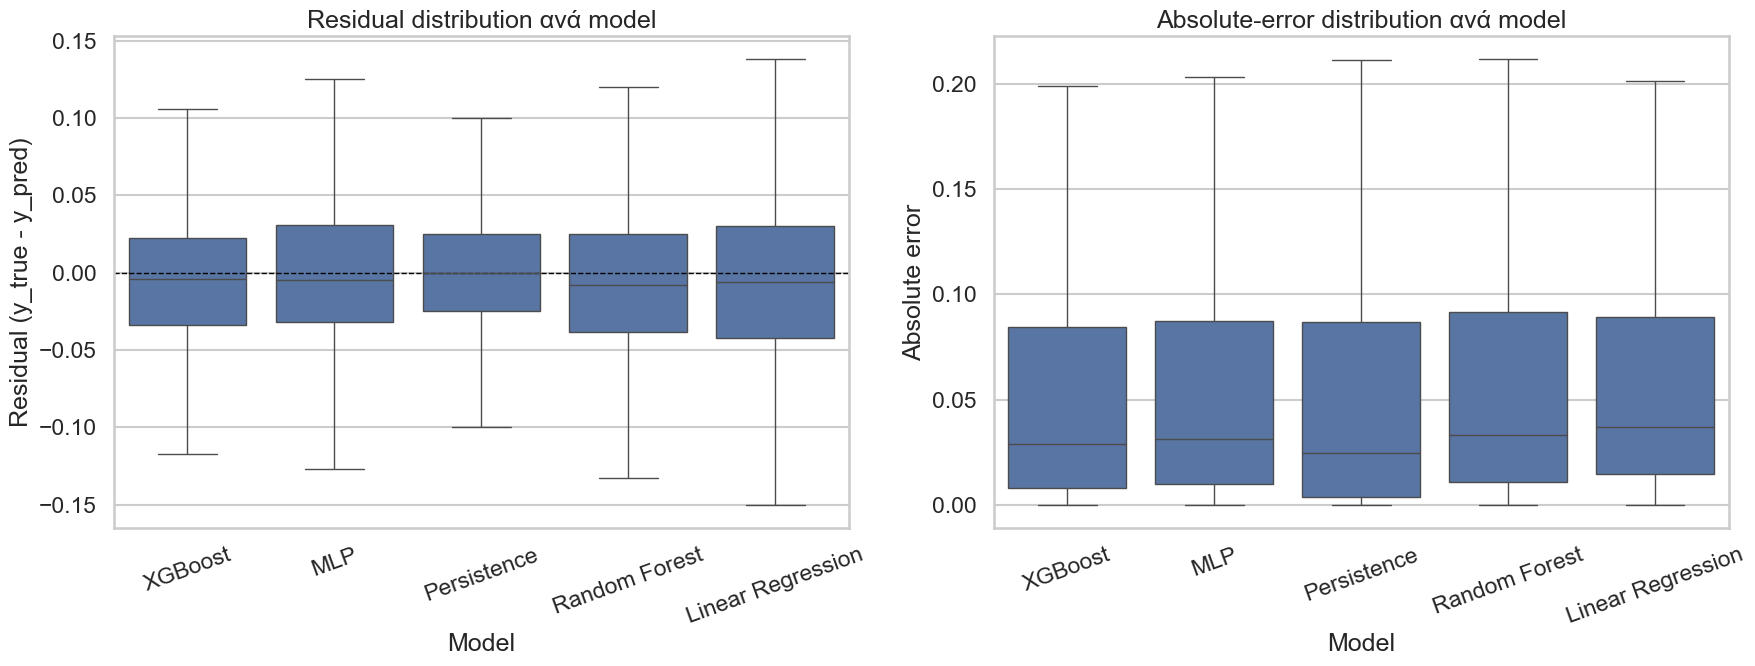

In [16]:
# ============================================================
# NB08 | Plot 1 - Residual and absolute-error distributions
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.boxplot(
    data=analysis_df,
    x="model",
    y="residual",
    order=model_order,
    ax=axes[0],
    showfliers=False,
)
axes[0].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
axes[0].set_title("Residual distribution ανά model")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Residual (y_true - y_pred)")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=analysis_df,
    x="model",
    y="abs_error",
    order=model_order,
    ax=axes[1],
    showfliers=False,
)
axes[1].set_title("Absolute-error distribution ανά model")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Absolute error")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Error percentiles ανά model

Τα percentiles είναι ιδιαίτερα χρήσιμα γιατί το aggregate `MAE` δεν δείχνει αν η βελτίωση ενός model είναι:

- ομοιόμορφη σε όλο το test space,
- κυρίως στα τυπικά cases,
- ή κυρίως στις δύσκολες ουρές της κατανομής.

Για thesis-ready ανάγνωση, τα `p90`, `p95`, `p99` δίνουν καθαρότερη εικόνα της tail difficulty.

In [17]:
# ============================================================
# NB08 | Error percentile summary and tail difficulty
# ============================================================

percentile_cols = [
    "model", "mae", "rmse", "p50_abs_error", "p75_abs_error",
    "p90_abs_error", "p95_abs_error", "p99_abs_error", "max_abs_error"
]
error_percentiles_df = error_distribution_df[percentile_cols].copy()

best_tail_model = (
    error_percentiles_df
    .sort_values(["p95_abs_error", "p99_abs_error", "mae"], kind="mergesort")
    .iloc[0]["model"]
)

print(f"Best model in tail-difficulty terms (primary p95 criterion): {best_tail_model}")
error_percentiles_df

Best model in tail-difficulty terms (primary p95 criterion): XGBoost


,model,mae,rmse,p50_abs_error,p75_abs_error,p90_abs_error,p95_abs_error,p99_abs_error,max_abs_error
0,XGBoost,0.065750,0.113494,0.028932,0.084449,0.179913,0.257870,0.437867,0.976231
1,MLP,0.068008,0.115343,0.031670,0.087198,0.182406,0.260973,0.444116,0.976393
2,Persistence,0.069832,0.130409,0.025000,0.087000,0.200000,0.298000,0.530000,0.988351
3,Random Forest,0.070963,0.118826,0.033263,0.091433,0.189404,0.269191,0.451679,0.973776
4,Linear Regression,0.072721,0.120307,0.037184,0.089481,0.186230,0.270350,0.468891,1.004591


## Cross-model disagreement και κοινή difficulty structure

Πριν περάσουμε στα operating regimes, είναι χρήσιμο να εξετάσουμε αν τα διαφορετικά models αποτυγχάνουν στις ίδιες observations ή σε διαφορετικές περιοχές του test space.

Αν η absolute-error structure είναι ισχυρά κοινή across models, τότε μέρος της forecasting δυσκολίας φαίνεται να είναι **intrinsic** στο operating space.  
Αν η error structure διαφοροποιείται ουσιαστικά, τότε υπάρχει και **model-specific** difficulty.

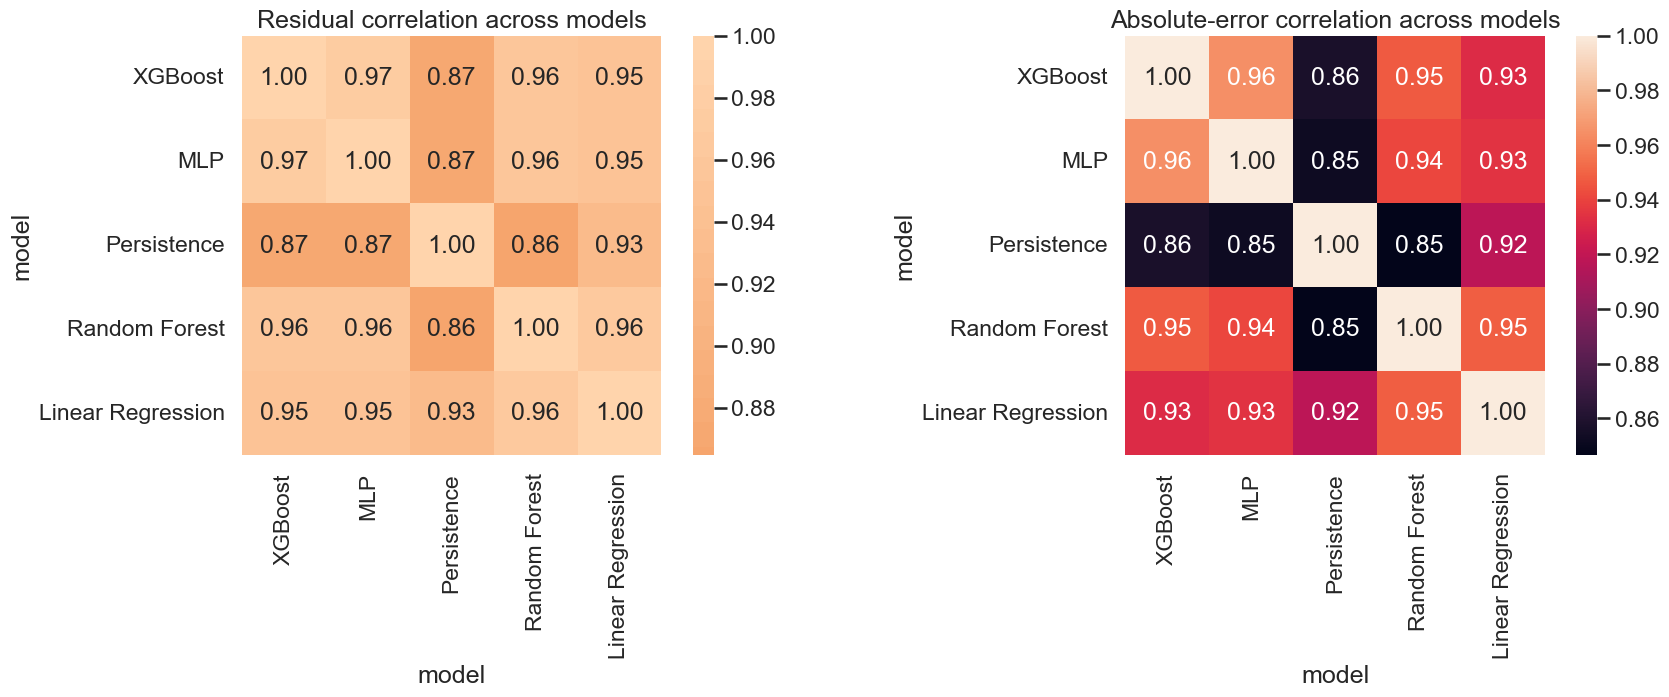

In [18]:
# ============================================================
# NB08 | Cross-model error structure
# ============================================================

# Wide matrices με κοινό row-level evaluation space
residual_wide = analysis_df.pivot(
    index=[PARK_ID_COLUMN, TIMESTAMP_COLUMN],
    columns="model",
    values="residual",
)

abs_error_wide = analysis_df.pivot(
    index=[PARK_ID_COLUMN, TIMESTAMP_COLUMN],
    columns="model",
    values="abs_error",
)

# Deterministic column order με βάση το benchmark ranking
residual_wide = residual_wide[model_order]
abs_error_wide = abs_error_wide[model_order]

residual_corr = residual_wide.corr()
abs_error_corr = abs_error_wide.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    residual_corr,
    annot=True,
    fmt=".2f",
    center=0.0,
    square=True,
    ax=axes[0],
)
axes[0].set_title("Residual correlation across models")

sns.heatmap(
    abs_error_corr,
    annot=True,
    fmt=".2f",
    square=True,
    ax=axes[1],
)
axes[1].set_title("Absolute-error correlation across models")

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# NB08 | Difficulty and disagreement summary
# ============================================================

row_level_difficulty = abs_error_wide.mean(axis=1).rename("mean_abs_error_across_models")
row_level_dispersion = abs_error_wide.std(axis=1).rename("std_abs_error_across_models")
row_level_winner = abs_error_wide.idxmin(axis=1).rename("best_model_rowwise")
row_level_loser = abs_error_wide.idxmax(axis=1).rename("worst_model_rowwise")

rowwise_summary_df = pd.concat(
    [row_level_difficulty, row_level_dispersion, row_level_winner, row_level_loser],
    axis=1,
).reset_index()

winner_counts_df = (
    rowwise_summary_df["best_model_rowwise"]
    .value_counts()
    .rename_axis("model")
    .reset_index(name="rowwise_win_count")
)
winner_counts_df["rowwise_win_share"] = winner_counts_df["rowwise_win_count"] / winner_counts_df["rowwise_win_count"].sum()
winner_counts_df["model"] = pd.Categorical(winner_counts_df["model"], categories=model_order, ordered=True)
winner_counts_df = winner_counts_df.sort_values("model", kind="mergesort").reset_index(drop=True)

quantile_threshold = row_level_difficulty.quantile(0.95)
hard_rows_df = rowwise_summary_df.loc[rowwise_summary_df["mean_abs_error_across_models"] >= quantile_threshold].copy()

hard_row_regime_summary = hard_rows_df.merge(
    analysis_df[[PARK_ID_COLUMN, TIMESTAMP_COLUMN, "wind_regime", "power_regime"]].drop_duplicates(),
    on=[PARK_ID_COLUMN, TIMESTAMP_COLUMN],
    how="left",
    validate="one_to_one",
)

hard_row_regime_distribution = (
    hard_row_regime_summary.groupby(["wind_regime", "power_regime"], observed=True)
    .size()
    .rename("hard_row_count")
    .reset_index()
    .sort_values("hard_row_count", ascending=False, kind="mergesort")
    .reset_index(drop=True)
)

print(f"95th percentile threshold for row-level mean absolute error: {quantile_threshold:.6f}")
print("Row-wise best-model frequency")
display(winner_counts_df)

print("Top hard-row regime combinations")
display(hard_row_regime_distribution.head(10))

95th percentile threshold for row-level mean absolute error: 0.263063
Row-wise best-model frequency


,model,rowwise_win_count,rowwise_win_share
0,XGBoost,164652,0.151566
1,MLP,175563,0.161610
2,Persistence,450756,0.414932
3,Random Forest,156038,0.143637
4,Linear Regression,139327,0.128254


Top hard-row regime combinations


,wind_regime,power_regime,hard_row_count
0,transition_9_12,near_rated_0.75_plus,5621
1,transition_9_12,high_output_0.50_0.75,4516
2,high_12_15,near_rated_0.75_plus,4304
3,transition_9_12,low_output_0.05_0.25,3984
4,transition_9_12,medium_output_0.25_0.50,3674
5,medium_6_9,high_output_0.50_0.75,3391
6,medium_6_9,near_rated_0.75_plus,2882
7,high_12_15,medium_output_0.25_0.50,2820
8,medium_6_9,medium_output_0.25_0.50,2451
9,high_12_15,low_output_0.05_0.25,2333


## Relative gain summaries έναντι Persistence και Linear Regression

Επειδή το `baseline_metrics.csv` είναι η canonical authority για το συνολικό test ranking, εδώ δεν ξαναγράφουμε το benchmark.  
Αντίθετα, υπολογίζουμε **diagnostic-relative gains** στο ίδιο test space ώστε να φανεί πόσο βελτιώνονται τα errors έναντι των δύο βασικών references:

- `Persistence` ως naive baseline,
- `Linear Regression` ως ισχυρό ερμηνεύσιμο linear reference.

In [20]:
# ============================================================
# NB08 | Relative gain summaries vs Persistence / Linear Regression
# ============================================================

reference_models = ["Persistence", "Linear Regression"]
reference_summary = (
    error_distribution_df[["model", "mae", "rmse", "p90_abs_error", "p95_abs_error"]]
    .rename(columns={
        "mae": "overall_mae",
        "rmse": "overall_rmse",
        "p90_abs_error": "overall_p90_abs_error",
        "p95_abs_error": "overall_p95_abs_error",
    })
)
ref_map = reference_summary.set_index("model")

relative_gain_rows = []
for _, row in reference_summary.iterrows():
    model_name = row["model"]
    for reference_model in reference_models:
        ref_row = ref_map.loc[reference_model]
        relative_gain_rows.append(
            {
                "model": model_name,
                "reference_model": reference_model,
                "mae_delta": row["overall_mae"] - ref_row["overall_mae"],
                "mae_relative_gain_pct": 100.0 * (ref_row["overall_mae"] - row["overall_mae"]) / ref_row["overall_mae"],
                "rmse_delta": row["overall_rmse"] - ref_row["overall_rmse"],
                "rmse_relative_gain_pct": 100.0 * (ref_row["overall_rmse"] - row["overall_rmse"]) / ref_row["overall_rmse"],
                "p90_delta": row["overall_p90_abs_error"] - ref_row["overall_p90_abs_error"],
                "p95_delta": row["overall_p95_abs_error"] - ref_row["overall_p95_abs_error"],
            }
        )

relative_gain_df = pd.DataFrame(relative_gain_rows)
relative_gain_df["model"] = pd.Categorical(relative_gain_df["model"], categories=model_order, ordered=True)
relative_gain_df = relative_gain_df.sort_values(["reference_model", "model"], kind="mergesort").reset_index(drop=True)
relative_gain_df

,model,reference_model,mae_delta,mae_relative_gain_pct,rmse_delta,rmse_relative_gain_pct,p90_delta,p95_delta
0,XGBoost,Linear Regression,-0.006971,9.586233,-0.006813,5.663298,-0.006317,-0.012480
1,MLP,Linear Regression,-0.004713,6.481041,-0.004964,4.126291,-0.003824,-0.009377
2,Persistence,Linear Regression,-0.002889,3.972291,0.010101,-8.396190,0.013770,0.027650
3,Random Forest,Linear Regression,-0.001758,2.417911,-0.001481,1.231410,0.003174,-0.001158
4,Linear Regression,Linear Regression,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,XGBoost,Persistence,-0.004083,5.846168,-0.016915,12.970463,-0.020087,-0.040130
6,MLP,Persistence,-0.001824,2.612527,-0.015065,11.552510,-0.017594,-0.037027
7,Persistence,Persistence,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,Random Forest,Persistence,0.001130,-1.618678,-0.011583,8.881862,-0.010596,-0.028809
9,Linear Regression,Persistence,0.002889,-4.136609,-0.010101,7.745835,-0.013770,-0.027650


## Regime-wise summaries και directional error rates

Σε αυτό το σημείο το notebook περνά από το aggregate distribution view στο **regime-wise diagnostic view**.

Πέρα από `MAE` και `RMSE`, εδώ προσθέτουμε και:

- `underprediction_rate`,
- `overprediction_rate`,
- `near_zero_rate`,
- και percentile-based difficulty indicators ανά regime.

Αυτό είναι πιο κατάλληλο για thesis-ready ερμηνεία, γιατί το πρόσημο του error και οι ουρές της κατανομής έχουν συχνά περισσότερη πληροφορία από έναν μόνο μέσο όρο.

In [21]:
# ============================================================
# NB08 | Aggregation helper
# ============================================================

def summarize_by_regime(df: pd.DataFrame, regime_col: str) -> pd.DataFrame:
    """
    Συνοψίζει residual behavior ανά model και regime.
    Προσθέτει directional rates και percentile-based summaries.
    """
    rows = []
    for model_name, model_df in df.groupby("model", observed=True):
        model_total = len(model_df)
        for regime_value, regime_df in model_df.groupby(regime_col, observed=True):
            rows.append(
                {
                    "model": model_name,
                    regime_col: regime_value,
                    "count": len(regime_df),
                    "share_of_model_rows": len(regime_df) / model_total,
                    "mean_residual": regime_df["residual"].mean(),
                    "median_residual": regime_df["residual"].median(),
                    "residual_std": regime_df["residual"].std(),
                    "mae": regime_df["abs_error"].mean(),
                    "rmse": np.sqrt(regime_df["squared_error"].mean()),
                    "p90_abs_error": regime_df["abs_error"].quantile(0.90),
                    "p95_abs_error": regime_df["abs_error"].quantile(0.95),
                    "underprediction_rate": regime_df["underpredict_flag"].mean(),
                    "overprediction_rate": regime_df["overpredict_flag"].mean(),
                    "near_zero_rate": regime_df["near_zero_flag"].mean(),
                }
            )

    summary = pd.DataFrame(rows)
    summary["model"] = pd.Categorical(summary["model"], categories=model_order, ordered=True)
    summary = summary.sort_values(["model", regime_col], kind="mergesort").reset_index(drop=True)
    return summary

In [22]:
# ============================================================
# NB08 | Wind-regime summaries
# ============================================================

wind_summary_df = summarize_by_regime(analysis_df, "wind_regime")
wind_summary_df.head(15)

,model,wind_regime,count,share_of_model_rows,mean_residual,median_residual,residual_std,mae,rmse,p90_abs_error,p95_abs_error,underprediction_rate,overprediction_rate,near_zero_rate
0,XGBoost,high_12_15,91678,0.084392,-0.002692,0.004308,0.173776,0.127840,0.173796,0.288383,0.363172,0.520027,0.479973,0.000000
1,XGBoost,low_3_6,261792,0.240986,-0.000035,-0.005992,0.078855,0.041806,0.078855,0.101997,0.158726,0.362490,0.637510,0.000004
2,XGBoost,medium_6_9,250978,0.231032,-0.000667,-0.010576,0.113072,0.070959,0.113073,0.172991,0.246171,0.392600,0.607400,0.000000
3,XGBoost,transition_9_12,190402,0.175270,-0.000569,-0.011600,0.153880,0.109500,0.153881,0.255183,0.328590,0.446739,0.553261,0.000000
4,XGBoost,very_high_15_plus,52959,0.048750,0.003240,0.010132,0.146575,0.092302,0.146609,0.246592,0.333796,0.604317,0.395683,0.000000
5,XGBoost,very_low_<3,238527,0.219570,-0.000507,-0.002429,0.055704,0.021864,0.055706,0.049424,0.090183,0.354182,0.645818,0.000000
6,MLP,high_12_15,91678,0.084392,0.013404,0.025782,0.176636,0.133247,0.177143,0.291299,0.367609,0.570060,0.429940,0.000000
7,MLP,low_3_6,261792,0.240986,-0.000396,-0.007191,0.080005,0.043222,0.080006,0.104556,0.160464,0.356623,0.643377,0.000000
8,MLP,medium_6_9,250978,0.231032,0.001665,-0.009170,0.114599,0.072051,0.114610,0.175913,0.249109,0.410673,0.589327,0.000004
9,MLP,transition_9_12,190402,0.175270,0.006853,-0.006094,0.156002,0.111595,0.156152,0.258600,0.332669,0.474717,0.525283,0.000000


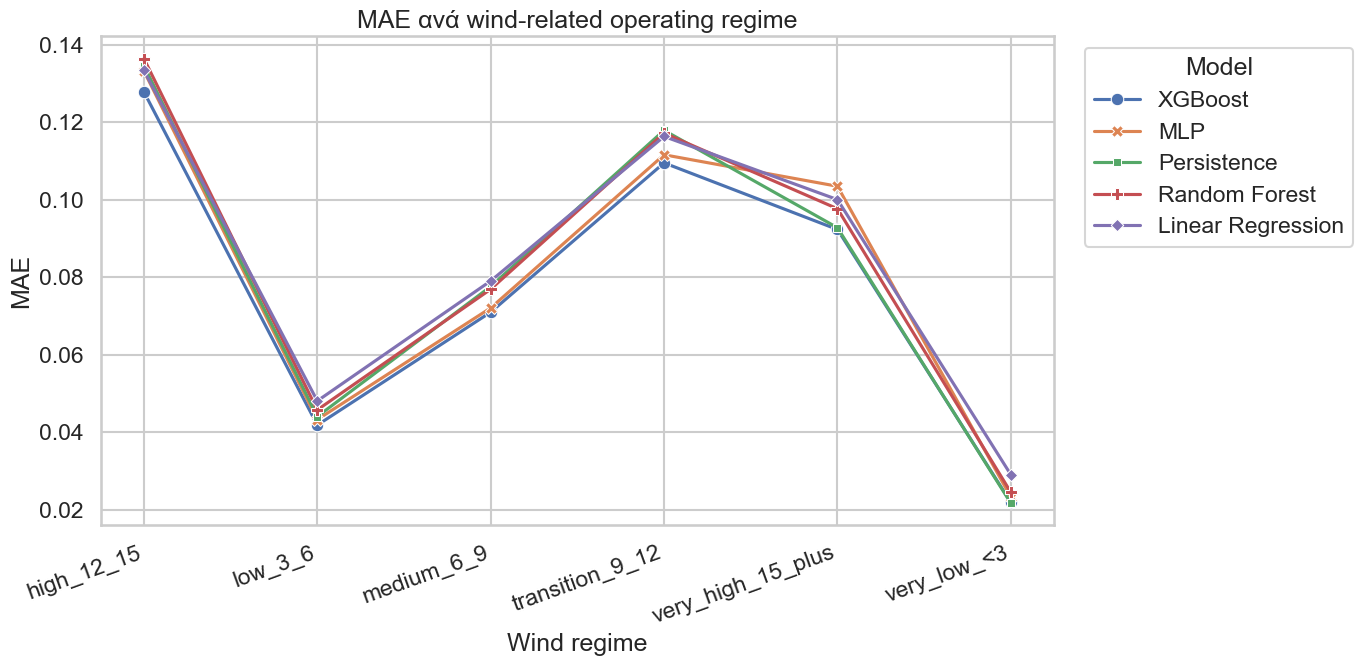

In [23]:
# ============================================================
# NB08 | Plot 2 - MAE by wind regime
# ============================================================

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=wind_summary_df,
    x="wind_regime",
    y="mae",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    hue_order=model_order,
)

plt.title("MAE ανά wind-related operating regime")
plt.xlabel("Wind regime")
plt.ylabel("MAE")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

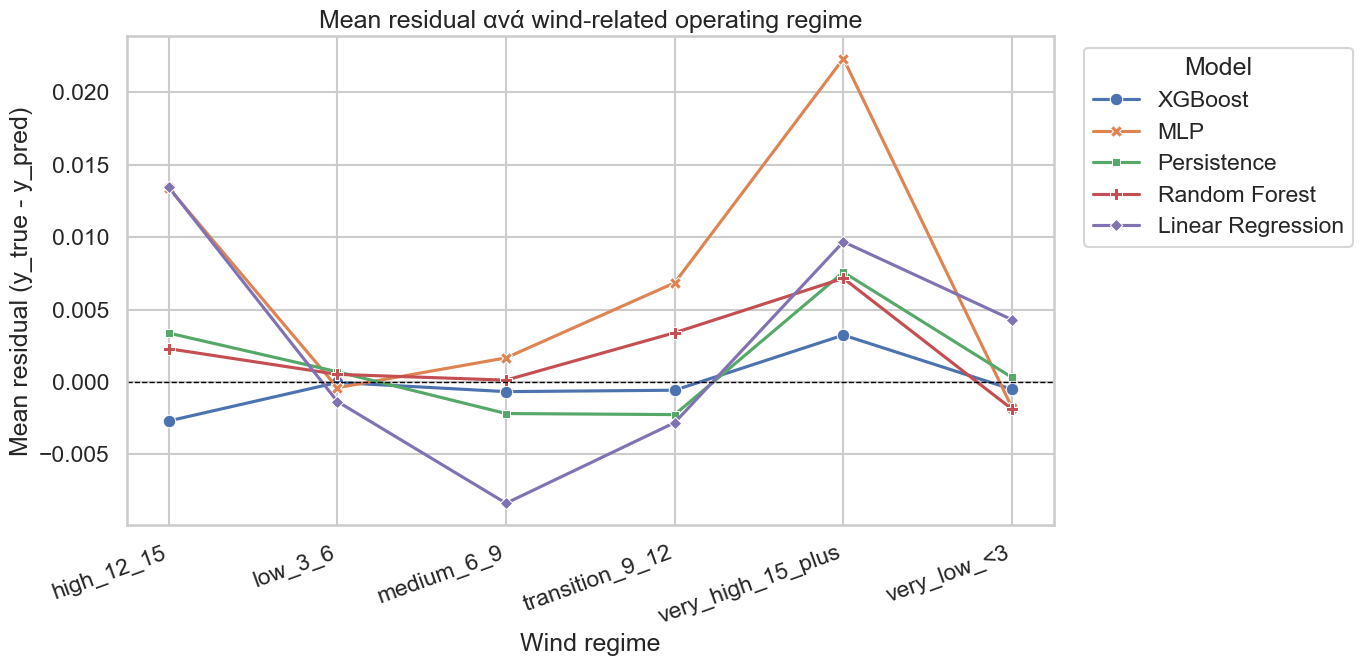

In [24]:
# ============================================================
# NB08 | Plot 3 - Mean signed residual by wind regime
# ============================================================

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=wind_summary_df,
    x="wind_regime",
    y="mean_residual",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    hue_order=model_order,
)

plt.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
plt.title("Mean residual ανά wind-related operating regime")
plt.xlabel("Wind regime")
plt.ylabel("Mean residual (y_true - y_pred)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

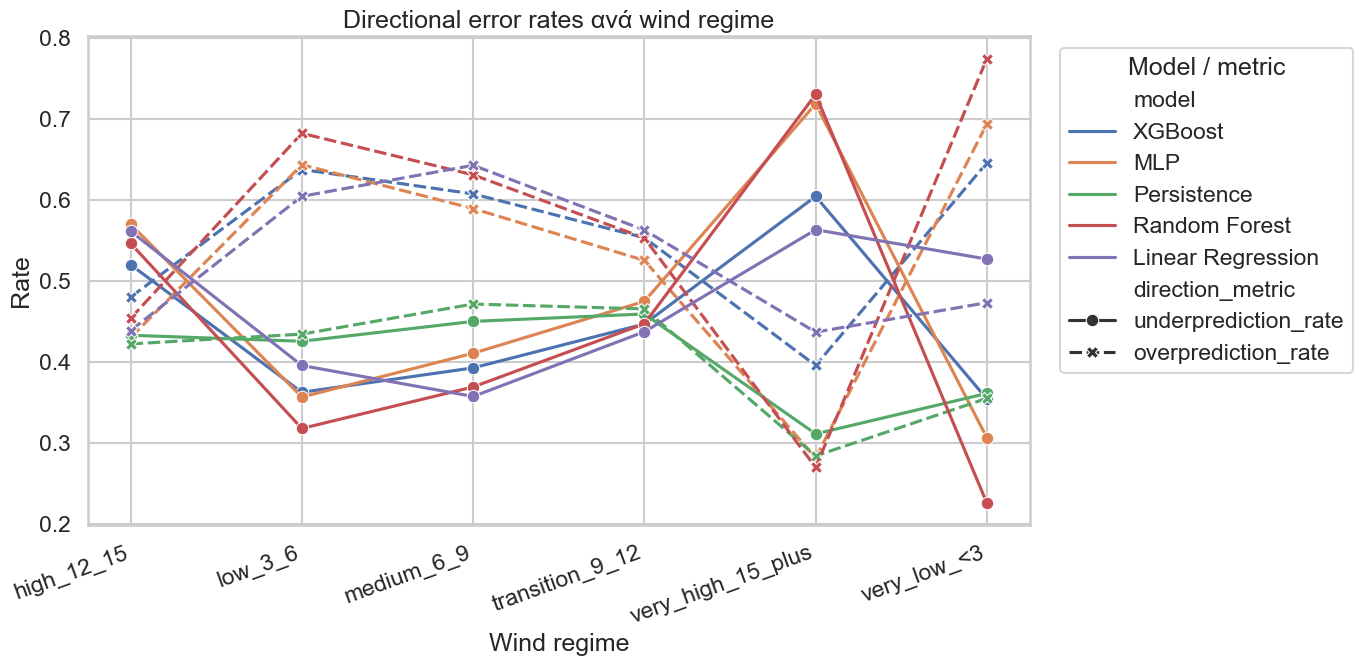

In [25]:
# ============================================================
# NB08 | Plot 4 - Directional error rates by wind regime
# ============================================================

wind_directional_df = wind_summary_df.melt(
    id_vars=["model", "wind_regime"],
    value_vars=["underprediction_rate", "overprediction_rate"],
    var_name="direction_metric",
    value_name="rate",
)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=wind_directional_df,
    x="wind_regime",
    y="rate",
    hue="model",
    style="direction_metric",
    markers=True,
    dashes=True,
    hue_order=model_order,
)
plt.title("Directional error rates ανά wind regime")
plt.xlabel("Wind regime")
plt.ylabel("Rate")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model / metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Ερμηνεία wind-regime diagnostics

Το wind-regime slicing είναι κρίσιμο επειδή η σχέση ανέμου-ισχύος είναι έντονα μη γραμμική.

Αν το error:

- αυξάνεται σε συγκεκριμένες wind-speed zones,
- αλλάζει πρόσημο συστηματικά,
- ή παραμένει δομημένο ακόμη και στους ισχυρότερους baselines,

τότε τα residuals δεν μπορούν να θεωρηθούν homogeneous aggregate noise.

Αυτό **δεν** αποδεικνύει turbine fault, degradation mechanism ή anomaly class.  
Δείχνει όμως ότι η residual structure εξαρτάται από το operating envelope και άρα αξίζει downstream diagnostic ανάγνωση.

In [26]:
# ============================================================
# NB08 | Power-regime summaries
# ============================================================

power_summary_df = summarize_by_regime(analysis_df, "power_regime")
power_summary_df.head(15)

,model,power_regime,count,share_of_model_rows,mean_residual,median_residual,residual_std,mae,rmse,p90_abs_error,p95_abs_error,underprediction_rate,overprediction_rate,near_zero_rate
0,XGBoost,high_output_0.50_0.75,64561,0.059430,0.082957,0.079061,0.179494,0.157647,0.197735,0.325793,0.389466,0.667725,0.332275,0.000000
1,XGBoost,low_output_0.05_0.25,295107,0.271654,-0.031702,-0.011529,0.102450,0.071129,0.107243,0.158705,0.223598,0.432369,0.567631,0.000003
2,XGBoost,medium_output_0.25_0.50,121002,0.111385,0.001576,0.017474,0.157189,0.123154,0.157196,0.255504,0.314246,0.546660,0.453340,0.000000
3,XGBoost,near_rated_0.75_plus,121628,0.111962,0.106668,0.054819,0.147430,0.116961,0.181971,0.310411,0.411417,0.815001,0.184999,0.000000
4,XGBoost,near_zero_0_0.05,484038,0.445569,-0.019929,-0.007702,0.042271,0.022994,0.046733,0.056065,0.087206,0.220384,0.779616,0.000000
5,MLP,high_output_0.50_0.75,64561,0.059430,0.092430,0.089261,0.179333,0.161285,0.201750,0.330996,0.397013,0.685228,0.314772,0.000000
6,MLP,low_output_0.05_0.25,295107,0.271654,-0.029419,-0.009358,0.102348,0.071130,0.106492,0.157773,0.220601,0.445977,0.554023,0.000000
7,MLP,medium_output_0.25_0.50,121002,0.111385,0.007179,0.022519,0.156450,0.122916,0.156614,0.255518,0.313099,0.561255,0.438745,0.000000
8,MLP,near_rated_0.75_plus,121628,0.111962,0.125943,0.078226,0.144465,0.132950,0.191655,0.324403,0.427976,0.913022,0.086978,0.000000
9,MLP,near_zero_0_0.05,484038,0.445569,-0.020382,-0.009192,0.041696,0.023619,0.046411,0.055540,0.086848,0.196995,0.803005,0.000004


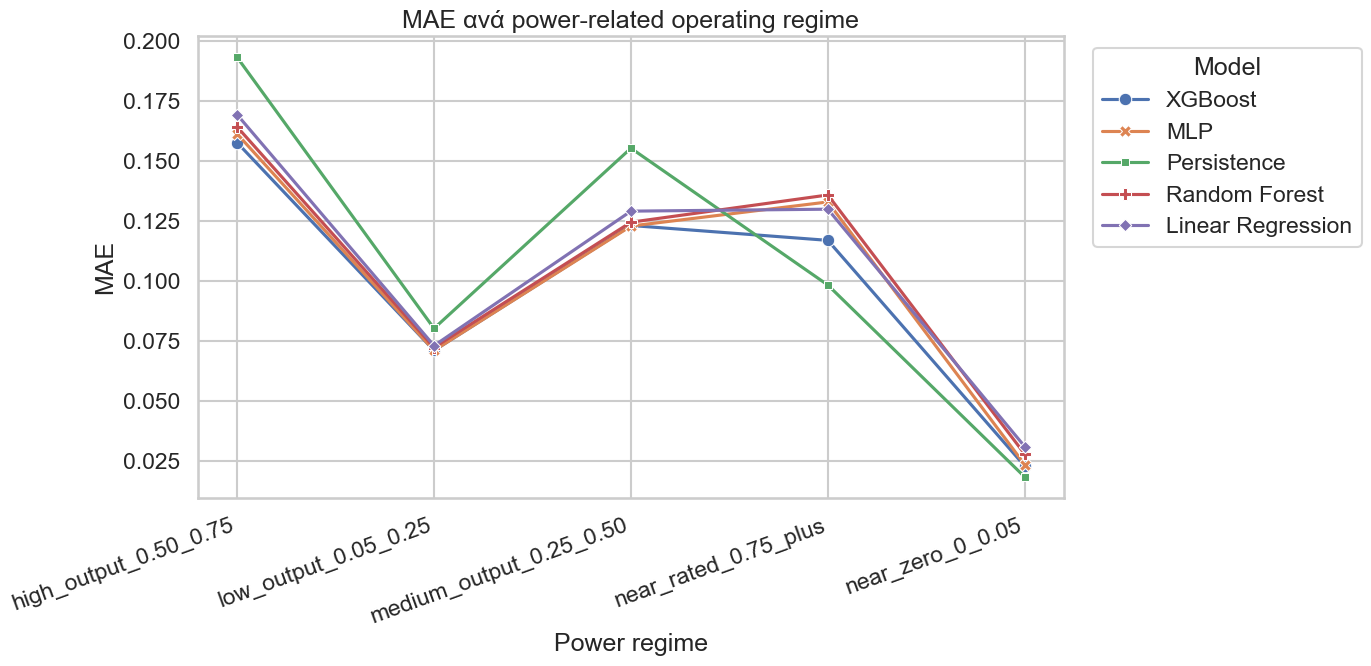

In [27]:
# ============================================================
# NB08 | Plot 5 - MAE by power regime
# ============================================================

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=power_summary_df,
    x="power_regime",
    y="mae",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    hue_order=model_order,
)

plt.title("MAE ανά power-related operating regime")
plt.xlabel("Power regime")
plt.ylabel("MAE")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

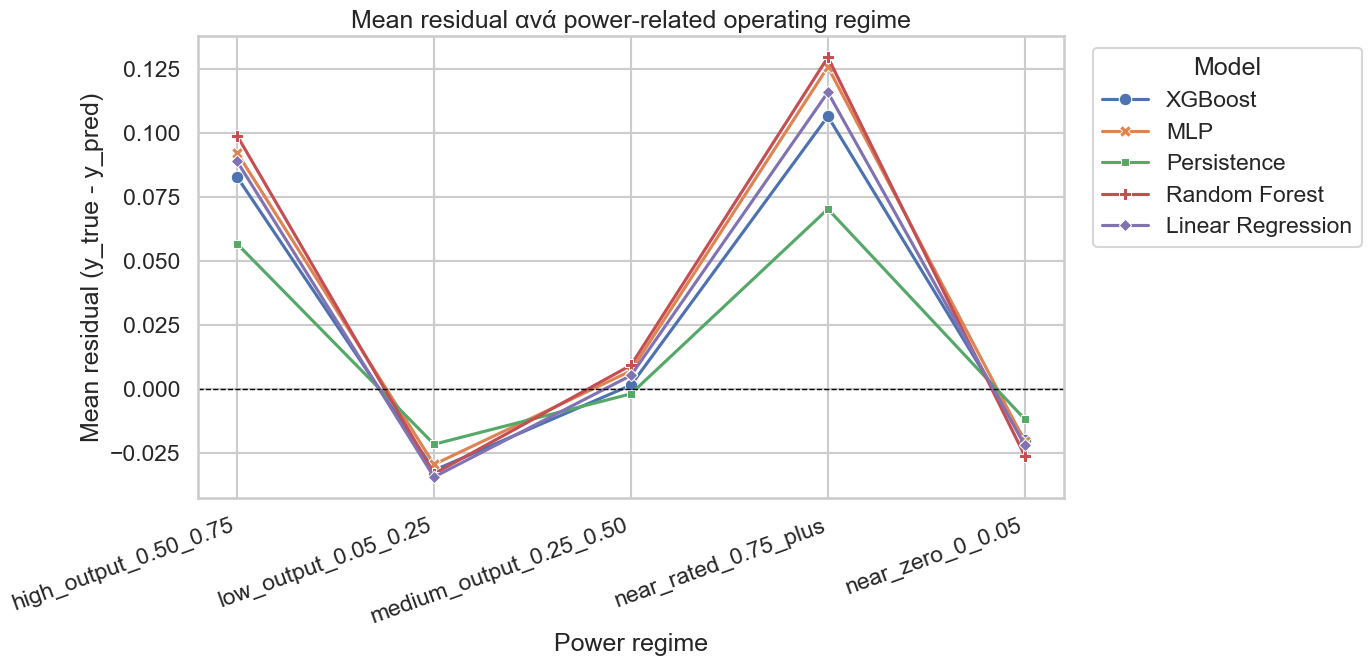

In [28]:
# ============================================================
# NB08 | Plot 6 - Mean signed residual by power regime
# ============================================================

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=power_summary_df,
    x="power_regime",
    y="mean_residual",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    hue_order=model_order,
)

plt.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
plt.title("Mean residual ανά power-related operating regime")
plt.xlabel("Power regime")
plt.ylabel("Mean residual (y_true - y_pred)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

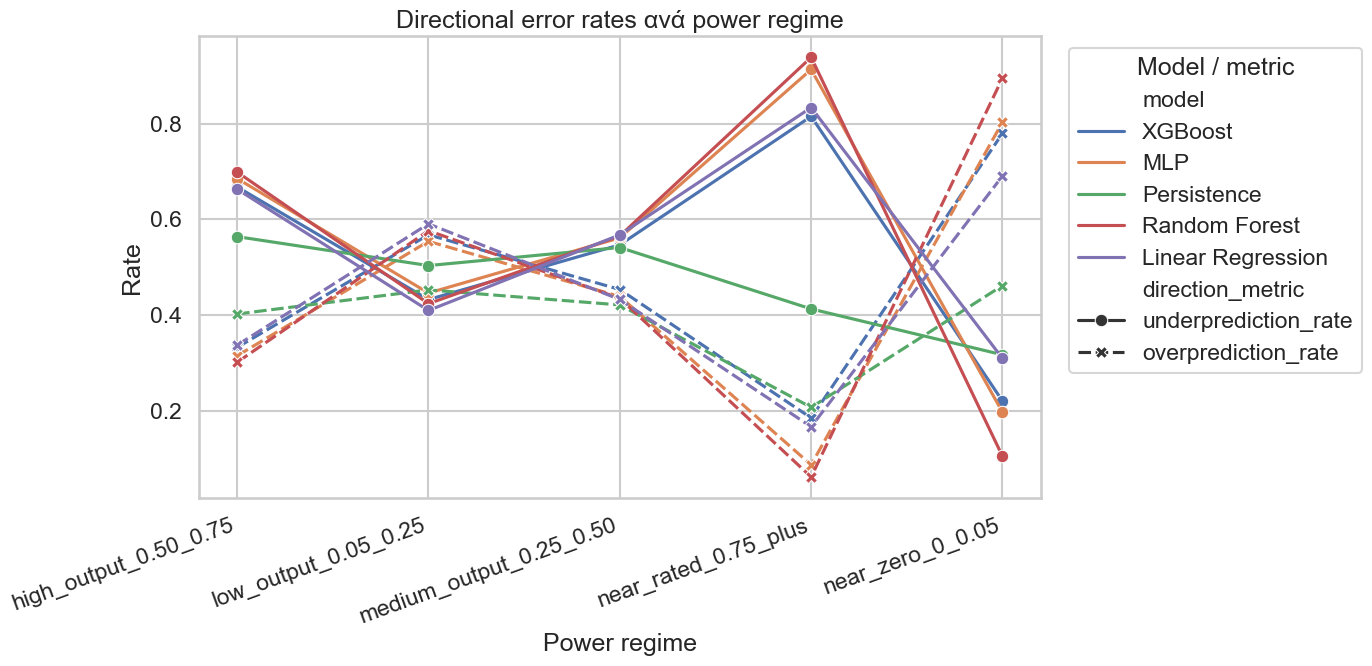

In [29]:
# ============================================================
# NB08 | Plot 7 - Directional error rates by power regime
# ============================================================

power_directional_df = power_summary_df.melt(
    id_vars=["model", "power_regime"],
    value_vars=["underprediction_rate", "overprediction_rate"],
    var_name="direction_metric",
    value_name="rate",
)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=power_directional_df,
    x="power_regime",
    y="rate",
    hue="model",
    style="direction_metric",
    markers=True,
    dashes=True,
    hue_order=model_order,
)
plt.title("Directional error rates ανά power regime")
plt.xlabel("Power regime")
plt.ylabel("Rate")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model / metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Joint operating-regime surface

Η 2D ανάλυση `wind regime × power regime` είναι ιδιαίτερα χρήσιμη γιατί δείχνει αν το error είναι δομημένο μόνο ως προς μία μεταβλητή ή ως προς πιο σύνθετο operating context.

Εδώ δεν χρειάζεται να αναλυθούν όλοι οι models σε heatmaps.  
Για thesis-ready καθαρότητα αρκεί:

- ένα **interpretable reference model** (`Linear Regression`)
- και το **best overall model** σύμφωνα με το current benchmark artifact

In [30]:
# ============================================================
# NB08 | Heatmap helper
# ============================================================

def make_regime_heatmap_table(
    df: pd.DataFrame,
    model_name: str,
    value_col: str = "abs_error",
) -> pd.DataFrame:
    """
    Δημιουργεί 2D table wind_regime x power_regime για ένα model.
    """
    model_df = df.loc[df["model"] == model_name].copy()

    heatmap_table = pd.pivot_table(
        model_df,
        values=value_col,
        index="wind_regime",
        columns="power_regime",
        aggfunc="mean",
        observed=True,
        sort=True,
    )

    return heatmap_table

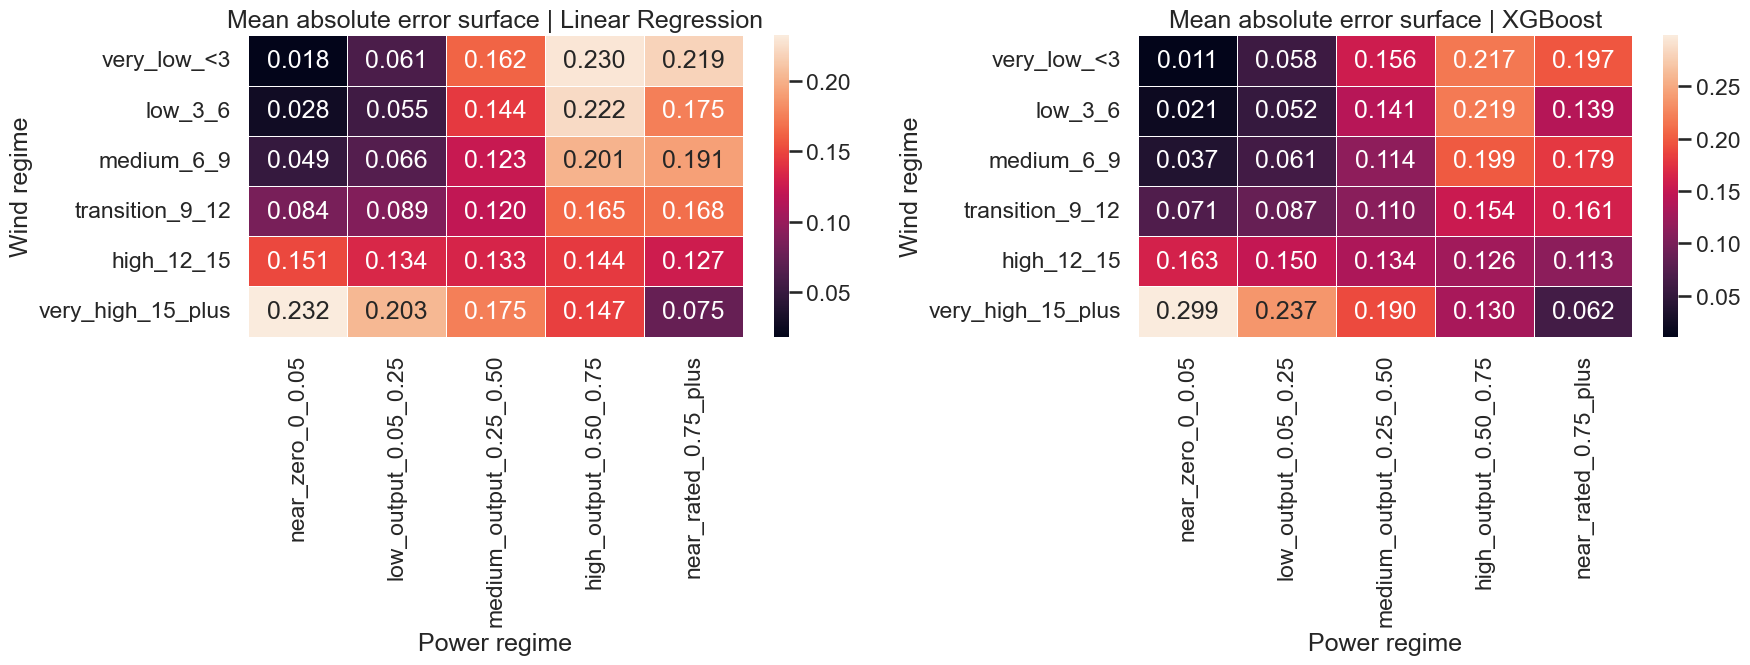

In [31]:
# ============================================================
# NB08 | Plot 8 - Joint wind x power regime heatmaps
# ============================================================

lr_heatmap = make_regime_heatmap_table(analysis_df, linear_reference_model, value_col="abs_error")
best_heatmap = make_regime_heatmap_table(analysis_df, best_overall_model, value_col="abs_error")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    lr_heatmap,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title(f"Mean absolute error surface | {linear_reference_model}")
axes[0].set_xlabel("Power regime")
axes[0].set_ylabel("Wind regime")

sns.heatmap(
    best_heatmap,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title(f"Mean absolute error surface | {best_overall_model}")
axes[1].set_xlabel("Power regime")
axes[1].set_ylabel("Wind regime")

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# NB08 | Regime-wise model ranking tables
# ============================================================

best_by_wind_regime = (
    wind_summary_df.sort_values(["wind_regime", "mae", "rmse"], kind="mergesort")
    .groupby("wind_regime", observed=True, as_index=False)
    .first()[["wind_regime", "model", "mae", "rmse", "mean_residual"]]
    .rename(columns={"model": "best_model_by_mae"})
)

best_by_power_regime = (
    power_summary_df.sort_values(["power_regime", "mae", "rmse"], kind="mergesort")
    .groupby("power_regime", observed=True, as_index=False)
    .first()[["power_regime", "model", "mae", "rmse", "mean_residual"]]
    .rename(columns={"model": "best_model_by_mae"})
)

print("Best model per wind regime")
display(best_by_wind_regime)

print("Best model per power regime")
display(best_by_power_regime)

Best model per wind regime


,wind_regime,best_model_by_mae,mae,rmse,mean_residual
0,high_12_15,XGBoost,0.127840,0.173796,-0.002692
1,low_3_6,XGBoost,0.041806,0.078855,-0.000035
2,medium_6_9,XGBoost,0.070959,0.113073,-0.000667
3,transition_9_12,XGBoost,0.109500,0.153881,-0.000569
4,very_high_15_plus,XGBoost,0.092302,0.146609,0.003240
5,very_low_<3,Persistence,0.021639,0.060973,0.000310


Best model per power regime


,power_regime,best_model_by_mae,mae,rmse,mean_residual
0,high_output_0.50_0.75,XGBoost,0.157647,0.197735,0.082957
1,low_output_0.05_0.25,XGBoost,0.071129,0.107243,-0.031702
2,medium_output_0.25_0.50,MLP,0.122916,0.156614,0.007179
3,near_rated_0.75_plus,Persistence,0.098357,0.187860,0.070426
4,near_zero_0_0.05,Persistence,0.018464,0.047634,-0.011709


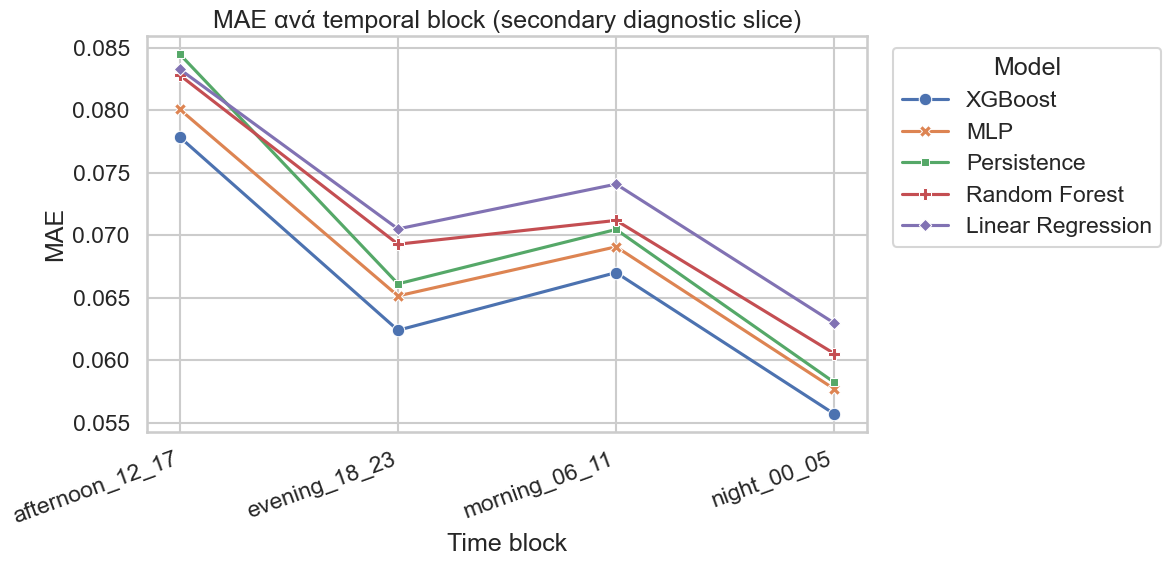

In [33]:
# ============================================================
# NB08 | Secondary temporal diagnostics
# ============================================================

time_summary_df = summarize_by_regime(analysis_df, "time_block")

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=time_summary_df,
    x="time_block",
    y="mae",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    hue_order=model_order,
)

plt.title("MAE ανά temporal block (secondary diagnostic slice)")
plt.xlabel("Time block")
plt.ylabel("MAE")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Καθαρός διαχωρισμός implemented / interpretation / future work

### 1) Τι είναι ήδη implemented μέσα στο `NB08`

Στο τρέχον notebook έχουν υλοποιηθεί:

- strict provenance / integrity checks,
- κοινό test-only row-level evaluation space,
- residual distribution overview,
- error percentile summaries ανά model,
- regime support audit,
- directional error rates ανά regime,
- cross-model disagreement / difficulty summary,
- relative gain summaries έναντι `Persistence` και `Linear Regression`,
- και compact downstream exports.

### 2) Πώς πρέπει να ερμηνευθούν τα ευρήματα

Τα outputs του notebook υποστηρίζουν **downstream forecasting diagnostics**.  
Επιτρέπουν προσεκτική discussion για structured error behavior, operating dependence και condition-awareness-oriented interpretation.

### 3) Τι παραμένει future work

Το `NB08` δεν υλοποιεί:

- anomaly detector,
- fault diagnosis module,
- PHM engine,
- prognostics model,
- RUL estimation,
- graph-based forecasting,
- sequence-based forecasting,
- ή νέο benchmark stage.

## Scientific interpretation

Τα αποτελέσματα του `NB08` δείχνουν ότι τα residuals των implemented forecasting baselines δεν πρέπει να αντιμετωπίζονται μόνο ως aggregate error.

Αντίθετα, η ανάλυση του notebook επιτρέπει να εξεταστεί αν:

- η residual magnitude αυξάνεται συστηματικά σε συγκεκριμένα operating regimes,
- η bias direction αλλάζει με το realized operating state,
- οι tail errors παραμένουν έντονες σε συγκεκριμένες περιοχές,
- και αν η row-level difficulty είναι κοινή across models ή εμφανίζει model-specific διαφοροποιήσεις.

Η ύπαρξη τέτοιων patterns **δεν** αποδεικνύει fault, anomaly class, degradation mechanism ή health-state inference.  
Ωστόσο, δείχνει ότι το forecasting residual αποτελεί χρήσιμο **diagnostic-space signal** όταν μελετάται σε συνάρτηση με operating conditions και benchmark-relative comparisons.

Με αυτή τη στενή έννοια, το notebook ενισχύει το thesis framing από:

**global benchmark reporting**

προς:

**benchmark + structured residual behavior analysis**

χωρίς να υπερβαίνει το current repository scope.

## Limitations

Η παρούσα ανάλυση πρέπει να διαβάζεται υπό τους εξής περιορισμούς:

1. Το dataset είναι **synthetic but realistic**, όχι πλήρως real SCADA fault dataset.
2. Τα operating regimes είναι **proxy regimes** και όχι ακριβή turbine controller states.
3. Δεν υπάρχουν fault labels, maintenance records ή degradation annotations μέσα στο notebook.
4. Η residual structure δεν αρκεί από μόνη της για:
   - fault diagnosis,
   - anomaly classification,
   - health-state inference,
   - ή RUL estimation.
5. Τα regime-wise findings πρέπει να ερμηνεύονται λαμβάνοντας υπόψη και την **ανισορροπία του regime support**.
6. Τα relative gains εδώ είναι **diagnostic summaries** πάνω στο ίδιο test-only space και όχι νέο official benchmark artifact.

Άρα το output του `NB08` αποτελεί:

- **diagnostics-aware extension** του forecasting benchmark stack,
- όχι νέο modeling stage,
- και όχι completed PHM module.

In [34]:
# ============================================================
# NB08 | Compact diagnostics exports and export manifest
# ============================================================

DIAGNOSTICS_DIR.mkdir(parents=True, exist_ok=True)

wind_summary_export_path = DIAGNOSTICS_DIR / "nb08_wind_regime_metrics.csv"
power_summary_export_path = DIAGNOSTICS_DIR / "nb08_power_regime_metrics.csv"
time_summary_export_path = DIAGNOSTICS_DIR / "nb08_time_block_metrics.csv"
wind_best_export_path = DIAGNOSTICS_DIR / "nb08_best_model_by_wind_regime.csv"
power_best_export_path = DIAGNOSTICS_DIR / "nb08_best_model_by_power_regime.csv"
error_distribution_export_path = DIAGNOSTICS_DIR / "nb08_error_distribution_overview.csv"
error_percentiles_export_path = DIAGNOSTICS_DIR / "nb08_error_percentiles.csv"
relative_gain_export_path = DIAGNOSTICS_DIR / "nb08_relative_gain_vs_references.csv"
rowwise_winner_export_path = DIAGNOSTICS_DIR / "nb08_rowwise_best_model_frequency.csv"
hard_regime_export_path = DIAGNOSTICS_DIR / "nb08_hard_row_regime_distribution.csv"
regime_support_export_path = DIAGNOSTICS_DIR / "nb08_regime_support_audit.csv"
export_manifest_path = DIAGNOSTICS_DIR / "nb08_export_manifest.csv"

wind_summary_df.to_csv(wind_summary_export_path, index=False)
power_summary_df.to_csv(power_summary_export_path, index=False)
time_summary_df.to_csv(time_summary_export_path, index=False)
best_by_wind_regime.to_csv(wind_best_export_path, index=False)
best_by_power_regime.to_csv(power_best_export_path, index=False)
error_distribution_df.to_csv(error_distribution_export_path, index=False)
error_percentiles_df.to_csv(error_percentiles_export_path, index=False)
relative_gain_df.to_csv(relative_gain_export_path, index=False)
winner_counts_df.to_csv(rowwise_winner_export_path, index=False)
hard_row_regime_distribution.to_csv(hard_regime_export_path, index=False)
pd.concat([wind_regime_counts, power_regime_counts, time_block_counts], axis=0, ignore_index=True).to_csv(regime_support_export_path, index=False)

export_manifest_df = pd.DataFrame(
    [
        {"artifact_name": wind_summary_export_path.name, "description": "Wind-regime metrics ανά model", "rows": len(wind_summary_df)},
        {"artifact_name": power_summary_export_path.name, "description": "Power-regime metrics ανά model", "rows": len(power_summary_df)},
        {"artifact_name": time_summary_export_path.name, "description": "Secondary temporal diagnostics", "rows": len(time_summary_df)},
        {"artifact_name": wind_best_export_path.name, "description": "Best model by MAE ανά wind regime", "rows": len(best_by_wind_regime)},
        {"artifact_name": power_best_export_path.name, "description": "Best model by MAE ανά power regime", "rows": len(best_by_power_regime)},
        {"artifact_name": error_distribution_export_path.name, "description": "Residual / absolute-error distribution overview ανά model", "rows": len(error_distribution_df)},
        {"artifact_name": error_percentiles_export_path.name, "description": "Error percentiles ανά model", "rows": len(error_percentiles_df)},
        {"artifact_name": relative_gain_export_path.name, "description": "Relative gains vs Persistence / Linear Regression", "rows": len(relative_gain_df)},
        {"artifact_name": rowwise_winner_export_path.name, "description": "Row-wise best-model frequency", "rows": len(winner_counts_df)},
        {"artifact_name": hard_regime_export_path.name, "description": "Distribution of hard rows across joint regimes", "rows": len(hard_row_regime_distribution)},
        {"artifact_name": regime_support_export_path.name, "description": "Support audit για wind / power / time regimes", "rows": len(wind_regime_counts) + len(power_regime_counts) + len(time_block_counts)},
    ]
)
export_manifest_df.to_csv(export_manifest_path, index=False)

print("Compact diagnostics artifacts exported successfully:")
display(export_manifest_df)

Compact diagnostics artifacts exported successfully:


,artifact_name,description,rows
0,nb08_wind_regime_metrics.csv,Wind-regime metrics ανά model,30
1,nb08_power_regime_metrics.csv,Power-regime metrics ανά model,25
2,nb08_time_block_metrics.csv,Secondary temporal diagnostics,20
3,nb08_best_model_by_wind_regime.csv,Best model by MAE ανά wind regime,6
4,nb08_best_model_by_power_regime.csv,Best model by MAE ανά power regime,5
5,nb08_error_distribution_overview.csv,Residual / absolute-error distribution overvie...,5
6,nb08_error_percentiles.csv,Error percentiles ανά model,5
7,nb08_relative_gain_vs_references.csv,Relative gains vs Persistence / Linear Regression,10
8,nb08_rowwise_best_model_frequency.csv,Row-wise best-model frequency,5
9,nb08_hard_row_regime_distribution.csv,Distribution of hard rows across joint regimes,30


## Συμπέρασμα

Το strengthened `NB08` επεκτείνει το current benchmark analysis από το επίπεδο των aggregate metrics στο επίπεδο των **structured residual diagnostics**.

Το βασικό συμπέρασμα είναι ότι το forecasting error δεν είναι ομοιογενές σε όλο το test space.  
Αντίθετα, παρουσιάζει διαφοροποίηση ως προς:

- την κατανομή residuals,
- τις ουρές της absolute-error κατανομής,
- τη bias direction,
- το regime support,
- και την κοινή ή μη κοινή difficulty across models.

Άρα το notebook ενισχύει την πτυχιακή σε καθαρά benchmark-safe βάση:

- κρατά strict downstream ρόλο,
- χρησιμοποιεί test-only evaluation logic,
- διατηρεί canonical exported-artifact usage,
- και προσθέτει richer diagnostics χωρίς scope expansion.

Το `NB08` παραμένει:

- forecasting-downstream,
- test-only,
- benchmark-safe,
- non-speculative,
- και πλήρως συμβατό με το current repo framing.

In [35]:
# ============================================================
# NB08 | Final sanity summary
# ============================================================

final_summary = {
    "test_rows": len(test_df),
    "test_columns": test_df.shape[1],
    "test_unique_parks": test_df[PARK_ID_COLUMN].nunique(),
    "combined_prediction_rows": len(all_pred_df),
    "expected_combined_rows": len(test_df) * len(EXPECTED_MODELS),
    "best_overall_model": best_overall_model,
    "wind_regime_count": analysis_df["wind_regime"].nunique(),
    "power_regime_count": analysis_df["power_regime"].nunique(),
    "time_block_count": analysis_df["time_block"].nunique(),
    "export_manifest_path": str(export_manifest_path),
}

pd.Series(final_summary)

test_rows                                                             1086336
test_columns                                                               47
test_unique_parks                                                         256
combined_prediction_rows                                              5431680
expected_combined_rows                                                5431680
best_overall_model                                                    XGBoost
wind_regime_count                                                           6
power_regime_count                                                          5
time_block_count                                                            4
export_manifest_path        C:\Users\diony\Desktop\WindPower_DigitalTwin\d...
dtype: object